## 1. FourCastNet v2 + modAFNO 內插模式 colab 教學版

## 在colab中模擬虛擬環境 (請使用google中的colab)

### download FCNV2 inference model, FCNv2 weight

*  step0: 連到自己的google雲端(方便拿取輸出結果)
*  step1: git clone couple_FCNV2_LLAT
*  step2: 下載FCNV2 weight

In [1]:
from google.colab import drive
drive.mount('/content/drive')
## Step1: download FCNV2 code from github
!git clone https://github.com/yungyun0721/global_model_FCNV2_colab_education.git

## Step2: download FCNV2 weight
%cd /content/global_model_FCNV2_colab_education
!wget 'https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip'
!unzip fcnv2_sm.zip
!mv fcnv2_sm FCNV2_weight
!rm -rf fcnv2_sm.zip


Mounted at /content/drive
Cloning into 'global_model_FCNV2_colab_education'...
remote: Enumerating objects: 97, done.
remote: Counting objects: 100% (97/97), done.
remote: Compressing objects: 100% (72/72), done.
remote: Total 97 (delta 41), reused 80 (delta 24), pack-reused 0 (from 0)
Receiving objects: 100% (97/97), 646.57 KiB | 2.97 MiB/s, done.
Resolving deltas: 100% (41/41), done.
/content/global_model_FCNV2_colab_education
--2026-09-17 14:35:16--  https://api.ngc.nvidia.com/v2/models/nvidia/modulus/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 44.225.106.180, 32.187.223.104
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|44.225.106.180|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/modulus/models/modulus_fcnv2_sm/versions/v0.2/files/fcnv2_sm.zip?ssec-algo=AES256&versionId=5EOzwamxNkLnRC.WfT.7pANCO1lZKGuV&ssec-key=JOM3u%2Fyc0SF6eWzL2HVIyv3W6f

### 建置FCNV2需要的環境
*  Step1: 下載各種packages (colab 沒有的環境)

In [2]:
# install the environment
!pip install -q -U xarray zarr gcsfs fsspec dask
!pip install -q metpy pysolar cartopy
!pip install -q torch_harmonics
!pip install -q ruamel.yaml
!pip install -q netcdf4 cfgrib pygrib
!pip install -q onnxruntime # if cpu
!pip install -U onnx onnxruntime-gpu # if gpu
!pip install -q xarray_regrid

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.4/1.4 MB 4.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 376.9/376.9 kB 23.9 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 91.4/91.4 kB 8.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 206.6/206.6 kB 17.1 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 1.5/1.5 MB 18.5 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 225.1/225.1 kB 20.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.1/9.1 MB 30.5 MB/s eta 0:00:00
ERROR: pip's dependency resolver does not currently take into account all the packages that are installed. This behaviour is the source of the following dependency conflicts.
distributed 2026.1.1 requires dask<2026.1.2,>=2026.1.1, but you have dask 2026.8.0 which is incompatible.
datasets 4.8.5 requires fsspec[http]<=2026.2.0,>=2023.1.0, but you have fsspec 2026.7.0 which is incompatible.
rapids-dask-dependency 26.2.0 requires dask==2026.1.1, bu

### 下載initial 資料

In [3]:
# download the initial condition ERA5 (2026042700)
%cd /content/global_model_FCNV2_colab_education
!python download_ERA5_from_google_for_model_input.py --scheduled-time 2026081800 --save-folder input_data
!python download_history_ncep_new.py --scheduled-time 2026081800 --save-folder input_data
!python download_IFS_new.py --scheduled-time 2026081800 --save-folder input_data

/content/global_model_FCNV2_colab_education
finish FCNV2 IC:2026080800
/content/global_model_FCNV2_colab_education/download_history_ncep_new.py:75: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 'isobaricInhPa' ('isobaricInhPa',) The recommendation is to set join explicitly for this case.
  upper_datasets = xr.merge([upper_datasets,temp],compat='override') if upper_datasets != None else  temp
/content/global_model_FCNV2_colab_education/download_history_ncep_new.py:75: FutureWarning: In a future version of xarray the default value for join will change from join='outer' to join='exact'. This change will result in the following ValueError: cannot be aligned with join='exact' because index/labels/sizes are not equal along these coordinates (dimensions): 

### FCNV2資料展示 (可以跳過)

/content/global_model_FCNV2_colab_education


Text(0, 0.5, 'Latitude')

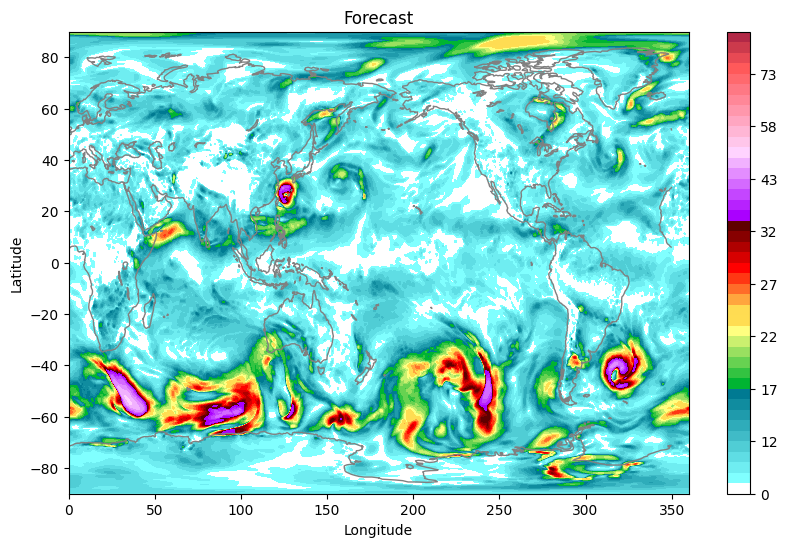

In [4]:
%cd /content/global_model_FCNV2_colab_education
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import pandas as pd

IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/ERA5_FCNV2_initial_condition.npy')
# IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/IFS_initial_condition.npy')
# IC_data = np.load('/content/global_model_FCNV2_colab_education/input_data/ncep_initial_condition.npy')
IC_flip = np.flip(IC_data, axis=1)
# variables order (73 variables)
ordering = [ "10u",  "10v", "100u", "100v",  "2t",  "sp",  "msl", "tcwv",
        "u50",  "u100", "u150", "u200", "u250", "u300", "u400", "u500", "u600", "u700", "u850", "u925", "u1000",
        "v50",  "v100", "v150", "v200", "v250", "v300", "v400", "v500", "v600", "v700", "v850", "v925", "v1000",
        "z50",  "z100", "z150", "z200", "z250", "z300", "z400", "z500", "z600", "z700", "z850", "z925", "z1000",
        "t50",  "t100", "t150", "t200", "t250", "t300", "t400", "t500", "t600", "t700", "t850", "t925", "t1000",
        "r50",  "r100", "r150", "r200", "r250", "r300", "r400", "r500", "r600", "r700", "r850", "r925", "r1000"]
index_ordering = 18
# index_ordering = 15
wsp_lev = [0,4,6,8,10,12,13,14,15,16,17,18,19,20,21,22,23,24,25,26,27,28,29,30,31,32,34,36,38,40,43,46,49,52,55,58,61,64,67,70,73,76,79,82,85]
wsp_color = ['#ffffff','#80ffff','#6fedf1','#5fdde4','#50cdd5','#40bbc7','#2facba','#1f9bac','#108c9f','#007a92',\
            '#00b432','#33c341','#67d251','#99e060','#cbf06f','#ffff80','#ffdd52','#ffdc52','#ffa63e','#ff6d29','#ff3713','#ff0000','#d70000','#af0000','#870000','#5f0000',\
            '#aa00ff','#b722fe','#c446ff','#d46aff','#e38dff','#f1b1ff','#ffd3ff',\
            '#ffc6ea','#ffb6d5','#ffa6c1','#ff97ac','#ff8798','#fe7884','#ff696e','#ff595a','#e74954','#cc3a4c','#b22846','#9a1941']

coast = pd.read_csv('/content/global_model_FCNV2_colab_education/plot/coast.csv')
coast_lon = coast.lon_map.copy()
coast_lon[coast.lon_map<0]=coast.lon_map[coast.lon_map<0]+360
coast_lon[(coast.lon_map<0) & (coast.lon_map>=-10)]=np.nan
coast.lon_map = coast_lon
# lon lat 850 hpa windspeed
IC_for_plot = np.sqrt(IC_flip[index_ordering,:,:]**2+IC_flip[index_ordering+13,:,:]**2)
xx, yy = np.meshgrid(np.linspace(0,359.75,1440), np.linspace(-90, 90, 721))
plt.figure(figsize=(10,6))
plt.plot(coast.lon_map,coast.lat_map,color='gray',linewidth=1)
plt.contourf(xx, yy, IC_for_plot, levels=wsp_lev, colors=wsp_color)
# plt.contourf(xx, yy, IC_flip[57,:,:], cmap="rainbow", levels=np.linspace(210,315,43))
plt.title('Forecast')
plt.colorbar()
plt.xlabel('Longitude');plt.ylabel('Latitude')

## FCNV2 預報
#### 目前使用GPU，預報120小時(每6小時一報)

In [5]:
# FCNV2 predicting
%cd /content/global_model_FCNV2_colab_education
!python inference_FCNV2.py --FCNV2_IC_path input_data/ERA5_FCNV2_initial_condition.npy --save_folder output_data --fore_hour 48 #--FCNV2_device cpu

/content/global_model_FCNV2_colab_education
initialize model ...
FCNV2 weight: FCNV2_weight, device: cuda
FCNV2 Model and weights are loaded.
save folder: output_data
load IC data and save ...
FCNV2 IC path: input_data/ERA5_FCNV2_initial_condition.npy
/content/global_model_FCNV2_colab_education/fourcastnetv2/layers.py:623: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=False):
/content/global_model_FCNV2_colab_education/fourcastnetv2/layers.py:632: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with amp.autocast(enabled=False):
finish : forecast 024 hr
finish : forecast 048 hr


### 預報完成後，查看結果
#### 劃出天氣圖

In [6]:
%cd /content/global_model_FCNV2_colab_education/plot/
!python plot850.py --data_source_file ../output_data --save_folder plot_850

/content/global_model_FCNV2_colab_education/plot
files count: 9
0
1
2
3
4
5
6
7
8


### 放到google雲端中方便下載

In [ ]:
%cd /content/global_model_FCNV2_colab_education
import os
os.makedirs('/content/drive/MyDrive/FCNV2_result/', exist_ok=True)
!cp -rf plot /content/drive/MyDrive/FCNV2_result/

/content/global_model_FCNV2_colab_education


#### modAFNO

In [10]:
!mkdir /content/global_model_FCNV2_colab_education/modAFNO_weight
%cd /content/global_model_FCNV2_colab_education/modAFNO_weight
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/earth-2/afno_dx_fi-v1-era5/versions/v0.1.0/files/fcinterp-modafno-2x2.mdlus --output-document fcinterp-modafno-2x2.mdlus
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/earth-2/afno_dx_fi-v1-era5/versions/v0.1.0/files/global_means.npy --output-document global_means.npy
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/earth-2/afno_dx_fi-v1-era5/versions/v0.1.0/files/global_stds.npy --output-document global_stds.npy
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/earth-2/afno_dx_fi-v1-era5/versions/v0.1.0/files/land_sea_mask.nc --output-document land_sea_mask.nc
!wget --content-disposition https://api.ngc.nvidia.com/v2/models/nvidia/earth-2/afno_dx_fi-v1-era5/versions/v0.1.0/files/orography.nc --output-document orography.nc


mkdir: cannot create directory ‘/content/global_model_FCNV2_colab_education/modAFNO_weight’: File exists
/content/global_model_FCNV2_colab_education/modAFNO_weight
--2026-09-17 14:46:52--  https://api.ngc.nvidia.com/v2/models/nvidia/earth-2/afno_dx_fi-v1-era5/versions/v0.1.0/files/fcinterp-modafno-2x2.mdlus
Resolving api.ngc.nvidia.com (api.ngc.nvidia.com)... 44.225.106.180, 32.187.223.104
Connecting to api.ngc.nvidia.com (api.ngc.nvidia.com)|44.225.106.180|:443... connected.
HTTP request sent, awaiting response... 302 Found
Location: https://xfiles.ngc.nvidia.com/org/nvidia/team/earth-2/models/afno_dx_fi-v1-era5/versions/v0.1.0/files/fcinterp-modafno-2x2.mdlus?ssec-algo=AES256&versionId=XOEfVncvVelpeUEXsG3Wrz5YTh3MmqZl&ssec-key=wrBIJpLAIFwU0D546h%2Byqwz4NNyxrRcsym1ExRDauk961Eh02jXBP%2B%2FXi51I9ERBXb0Sito9CP829t55EKwUpaplBj3asdxD3jhDSiBhaYeJtEbu4Xq3cmsxeSC35N8Vla4u%2FyEnb1HmEOFndpGekG7BdGIT70ozxUD3TSppiEA6bX3RerXdxTzNJgECD0GdXbfb1TlHcKXT%2F8fXLcTuqDSMv77%2F5N3HKWpFv39EKMfth84la5q0DrUCH

In [12]:
%cd /content/global_model_FCNV2_colab_education
!python inference_modAFNO.py -i output_data -s modAFNO_output -t 2026080800 -d cuda

/content/global_model_FCNV2_colab_education
start predict 000h
start predict 001h
start predict 002h
start predict 003h
start predict 004h
start predict 005h
start predict 006h
start predict 007h
start predict 008h
start predict 009h
start predict 010h
start predict 011h
start predict 012h
start predict 013h
start predict 014h
start predict 015h
start predict 016h
start predict 017h
start predict 018h
start predict 019h
start predict 020h
start predict 021h
start predict 022h
start predict 023h
start predict 024h
start predict 025h
start predict 026h
start predict 027h
start predict 028h
start predict 029h
start predict 030h
start predict 031h
start predict 032h
start predict 033h
start predict 034h
start predict 035h
start predict 036h
start predict 037h
start predict 038h
start predict 039h
start predict 040h
start predict 041h
start predict 042h
start predict 043h
start predict 044h
start predict 045h
start predict 046h
start predict 047h
Traceback (most recent call last):
  File "/

預報內插完成後，查看結果
劃出天氣圖

In [16]:
%cd /content/global_model_FCNV2_colab_education/plot/
!python plot850_interp.py --data_source_file ../test_interpolation_IFS --save_folder plot_850_interp

/content/global_model_FCNV2_colab_education/plot
files count: 48
0
1
2
3
4
5
6
7
8
9
10
11
12
13
14
15
16
17
18
19
20
21
22
23
24
25
26
27
28
29
30
31
32
33
34
35
36
37
38
39
40
41
42
43
44
45
46
47


In [17]:
%cd /content/global_model_FCNV2_colab_education
import os
os.makedirs('/content/drive/MyDrive/FCNV2_result/', exist_ok=True)
!cp -rf plot /content/drive/MyDrive/FCNV2_result/

/content/global_model_FCNV2_colab_education
